MobileNetV2 + Quantization Aware Training (QAT)
Progressive 5-Phase Fine-Tuning
================================================
Optimised for Kaggle Notebooks · GPU P100 (16 GB)

* Phase 1 → All layers frozen       | FER-13  | lr = 7e-4
* Phase 2 → Top 90 layers frozen     | FER-13  | lr = 7e-4
* Phase 3 → Top 40 layers frozen     | FER-13  | lr = 3e-6
* Phase 4 → Top 40 layers frozen     | RAF-DB  | lr = 3e-6
* Phase 5 → Top 40 layers frozen     | AFD-DB  | lr = 5e-6

Install (Kaggle already has TF 2.x; only tfmot may be missing):
    pip install tensorflow-model-optimization -q

    After installation, restart the kernal

In [ ]:
!pip install -q --upgrade numpy
!pip install -q --upgrade tensorflow tensorflow-model-optimization
import importlib, pkg_resources
importlib.reload(pkg_resources)

In [ ]:

# ══════════════════════════════════════════════════════════════════════
# USAGE NOTES
# ══════════════════════════════════════════════════════════════════════
#
# Kaggle notebook setup cell (run before this script):
# -------------------------------------------------------
# !pip install tensorflow-model-optimization -q
#
# Expected dataset structure (adjust paths in CONFIG section above):
# -------------------------------------------------------
# /kaggle/input/fer2013/
#   train/
#     angry/  disgust/  fear/  happy/  neutral/  sad/  surprise/
#   val/
#     angry/  disgust/  fear/  happy/  neutral/  sad/  surprise/
#
# /kaggle/input/raf-db/
#   train/  val/   (same class layout)
#
# All 4 phase .keras files + final_qat_int8.tflite land in:
#   /kaggle/working/qat_phases/
#
# TensorBoard (run in a separate cell):
# -------------------------------------------------------
# %load_ext tensorboard
# %tensorboard --logdir /kaggle/working/qat_phases/tb_logs
#
# P100 memory notes:
# -------------------------------------------------------
# • BATCH_SIZE=32 at 224×224 uses ~6 GB GPU RAM with QAT overhead.
# • Set BATCH_SIZE=16 if you add heavy augmentation or hit OOM.
# • Mixed precision (MIXED_PREC=True) cuts memory ~30% on P100.
# • ds.cache() is used; make sure /kaggle/working has enough disk.
#   If RAM is tight, remove .cache() from build_dataset().
# 
# ══════════════════════════════════════════════════════════════════════

# Import Library 

In [1]:
# ── stdlib ─────────────────────────────────────────────────────────────
import os, gc, time, warnings
warnings.filterwarnings("ignore")

In [2]:
# ── third-party ────────────────────────────────────────────────────────
import numpy as np
import tensorflow as tf
import tensorflow_model_optimization as tfmot

print(f"TensorFlow  : {tf.__version__}")
print(f"tfmot       : {tfmot.__version__}")
print(f"GPU devices : {tf.config.list_physical_devices('GPU')}")

2026-05-29 08:19:28.319923: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780042768.342694     120 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780042768.350247     120 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780042768.368442     120 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780042768.368459     120 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780042768.368462     120 computation_placer.cc:177] computation placer alr

TensorFlow  : 2.19.1
tfmot       : 0.8.1
GPU devices : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, accuracy_score, precision_score
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration

## Dataset Path, Model input size, Training size, Phase Schedule

In [4]:
# ── Paths ──────────────────────────────────────────────────────────────
FER13_TRAIN  = "/kaggle/input/datasets/msambare/fer2013/train"
FER13_VAL    = "/kaggle/input/datasets/msambare/fer2013/test"
RAFDB_TRAIN  = "/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/train"
RAFDB_VAL    = "/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/test"
AFD_TRAIN    = "/kaggle/input/datasets/qystyy/asian-emotion-faces-split/dataset_split/train"
AFD_VAL      = "/kaggle/input/datasets/qystyy/asian-emotion-faces-split/dataset_split/test"
OUTPUT_DIR   = "/kaggle/working/qat_phases"

# ── Model ──────────────────────────────────────────────────────────────
NUM_CLASSES  = 7          # anger disgust fear happy neutral sad surprise
IMAGE_SIZE   = (224, 224)
CHANNELS     = 3

# ── Training ───────────────────────────────────────────────────────────
BATCH_SIZE   = 32         # safe for P100 16 GB at 224×224
MIXED_PREC   = True       # float16 activations → 2× throughput on P100

# ── Phase schedule ─────────────────────────────────────────────────────
#   (name, freeze_spec, dataset, lr, max_epochs, early_stop_patience)
#   freeze_spec: "ALL" | int N  (freeze layers 0..N-1)
PHASES = [                                                  # V2-9th Trial - To export the model zip folder for the model to run 
    ("phase1_all_frozen", "ALL",   "fer13",  7e-4, 15, 4),  # Change all the setting back to the same as 9th trial
    ("phase2_top90_frozen",  90,   "fer13",  7e-4, 15, 4),  # 
    ("phase3_top40_frozen",  40,   "fer13",  3e-6, 30, 5),  # 
    ("phase4_rafdb",         40,   "rafdb",  3e-6, 75, 5),  # 
    ("phase5_afd",           40,   "afd",    5e-6, 120, 5), # 
]
os.makedirs(OUTPUT_DIR, exist_ok=True)
print('Config OK - output dir:', OUTPUT_DIR)

Config OK - output dir: /kaggle/working/qat_phases


# Dataset

## Dataset Augmentation

In [5]:

def augment_train(image, label):
    """
    Light augmentation — enough to regularise without destroying subtle
    facial expressions.  Keep it mild because QAT already introduces
    extra noise via fake-quant ops.
    """
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.12)
    image = tf.image.random_contrast(image, lower=0.88, upper=1.12)
    # Mild random crop: zoom in up to 10 %
    shape  = tf.shape(image)
    crop_h = tf.cast(tf.cast(shape[0], tf.float32) * 0.92, tf.int32)
    crop_w = tf.cast(tf.cast(shape[1], tf.float32) * 0.92, tf.int32)
    image  = tf.image.resize(image, IMAGE_SIZE)
    image  = tf.clip_by_value(image, 0.0, 1.0)
    return image, label

print("Data aug done")

Data aug done


In [6]:
# FER-13 alphabetical order — Keras default, no remapping needed
FER13_CLASSES = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

# RAF-DB: folder name → correct emotion index (matching FER-13 order above)
# RAF-DB numbering: 1=Surprise,2=Fear,3=Disgust,4=Happy,5=Sad,6=Angry,7=Neutral
RAFDB_FOLDER_TO_EMOTION = {
    '1': 6,   # Surprise → index 6
    '2': 2,   # Fear     → index 2
    '3': 1,   # Disgust  → index 1
    '4': 3,   # Happy    → index 3
    '5': 5,   # Sad      → index 5
    '6': 0,   # Angry    → index 0
    '7': 4,   # Neutral  → index 4
}


def build_dataset(directory, training, class_mapping=None):
    """
    class_mapping: dict {original_index: correct_index}
                   None = use Keras alphabetical order as-is (FER-13)
    """
    ds = tf.keras.utils.image_dataset_from_directory(
        directory,
        image_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        label_mode='categorical',
        shuffle=training,
        seed=42,
        interpolation='bilinear',
    )

    # Remap labels if a mapping is provided
    if class_mapping is not None:
        # Build a lookup tensor: index i → correct index
        n_classes  = NUM_CLASSES
        lookup     = np.zeros(n_classes, dtype=np.int32)
        for orig, correct in class_mapping.items():
            lookup[int(orig)] = correct
        lookup_tensor = tf.constant(lookup, dtype=tf.int32)

        def remap_labels(images, labels):
            # labels shape: (batch, n_classes) one-hot
            orig_indices  = tf.argmax(labels, axis=1, output_type=tf.int32)
            new_indices   = tf.gather(lookup_tensor, orig_indices)
            new_labels    = tf.one_hot(new_indices, depth=n_classes)
            return images, new_labels

        ds = ds.map(remap_labels, num_parallel_calls=tf.data.AUTOTUNE)

    # Normalise
    ds = ds.map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y),
                num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.map(augment_train, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


def get_datasets(name):
    if name == 'fer13':
        return build_dataset(FER13_TRAIN, True), build_dataset(FER13_VAL, False)
    elif name == 'rafdb':
        # Build index mapping: Keras assigns 0..6 alphabetically to '1'..'7'
        # so original index = folder_name - 1
        index_mapping = {i: RAFDB_FOLDER_TO_EMOTION[str(i+1)] for i in range(7)}
        return (build_dataset(RAFDB_TRAIN, True,  index_mapping),
                build_dataset(RAFDB_VAL,   False, index_mapping))
    elif name == 'afd':
        return build_dataset(AFD_TRAIN, True), build_dataset(AFD_VAL, False)
    elif name == 'vea':
        return build_dataset(VEA_TRAIN, True), build_dataset(VEA_VAL, False)
    raise ValueError(f'Unknown dataset: {name}')

print('Dataset pipeline ready.')

Dataset pipeline ready.


In [7]:
# Sanity check — print a few label distributions per dataset
for name in ['fer13', 'rafdb','afd']:
    train_ds, _ = get_datasets(name)
    label_counts = np.zeros(NUM_CLASSES, dtype=int)
    for _, labels in train_ds.take(20):
        indices = np.argmax(labels.numpy(), axis=1)
        for idx in indices:
            label_counts[idx] += 1
    print(f'\n{name} label sample (first 20 batches):')
    for i, (emotion, count) in enumerate(zip(FER13_CLASSES, label_counts)):
        print(f'  {i} {emotion:<10} : {count}')

Found 28709 files belonging to 7 classes.


I0000 00:00:1780042816.963355     120 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 7178 files belonging to 7 classes.

fer13 label sample (first 20 batches):
  0 angry      : 71
  1 disgust    : 17
  2 fear       : 95
  3 happy      : 187
  4 neutral    : 105
  5 sad        : 108
  6 surprise   : 57
Found 12271 files belonging to 7 classes.
Found 3068 files belonging to 7 classes.

rafdb label sample (first 20 batches):
  0 angry      : 41
  1 disgust    : 39
  2 fear       : 11
  3 happy      : 229
  4 neutral    : 123
  5 sad        : 125
  6 surprise   : 72
Found 672 files belonging to 7 classes.
Found 168 files belonging to 7 classes.

afd label sample (first 20 batches):
  0 angry      : 93
  1 disgust    : 93
  2 fear       : 93
  3 happy      : 92
  4 neutral    : 89
  5 sad        : 90
  6 surprise   : 90


# Base Model

MobileNetV2 pretrained on ImageNet.
Custom head: GlobalAvgPool → BN → Dropout → Dense(NUM_CLASSES).

Notes for QAT compatibility:

* Use ReLU6 activations (MobileNetV2 default) — they quantise cleanly.
* Avoid Lambda layers; they break QAT graph tracing.
* The final Dense uses float32 output even under mixed precision  (required for stable softmax / loss computation)

In [8]:
# 1. Build base model
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(*IMAGE_SIZE, CHANNELS),
    include_top=False,
    weights='imagenet',
)

x = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)  # (None, 1280)
x = tf.keras.layers.Dense(512, activation='relu')(x)
x = tf.keras.layers.Dropout(0.4)(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.Dropout(0.3)(x)
output = tf.keras.layers.Dense(
    NUM_CLASSES,
    activation='softmax',
    dtype='float32',
    name='predictions',
)(x)

model = tf.keras.Model(base_model.input, outputs=output, name='MobileNetV2_QAT')

# 2. Save the clean base model BEFORE quantizing
base_save_path = os.path.join(OUTPUT_DIR, 'base_model.keras')
model.save(base_save_path)
print('Base model saved.')

print(f'Total layers : {len(model.layers)}')
print(f'Total params : {model.count_params():,}')
model.summary()

9406464/9406464 [==============================] - 2s 0us/step
Base model saved.
Total layers : 160
Total params : 3,046,983
Model: "MobileNetV2_QAT"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 Conv1 (Conv2D)              (None, 112, 112, 32)         864       ['input_1[0][0]']             
                                                                                                  
 bn_Conv1 (BatchNormalizati  (None, 112, 112, 32)         128       ['Conv1[0][0]']               
 on)                                                                                              
                                                          

# QAT (RUN ONCE ONLY)

    Insert fake-quantisation nodes throughout the model graph.

    Key detail for MobileNetV2:
      tfmot.quantize_model() handles DepthwiseConv2D and BatchNorm correctly
      in TF ≥ 2.9 — it folds BN into the preceding conv for inference
      and inserts observer nodes for weight + activation quantisation.

    The returned model has the SAME layer structure but every eligible
    op now has a fake-quant wrapper.  Frozen layers still participate
    in the forward pass (fake-quant active) but receive no gradients.

In [9]:
# ══════════════════════════════════════════════════════════════════════
# 5.  QAT WRAPPER  (RUN ONCE ONLY)
# ══════════════════════════════════════════════════════════════════════
print('Inserting fake-quantisation nodes ...')
model = tfmot.quantization.keras.quantize_model(model)
print(f'QAT model — layers after wrapping: {len(model.layers)}')
print('Fake-quant nodes inserted. QAT wrapper will be carried through all phases.')

Inserting fake-quantisation nodes ...
QAT model — layers after wrapping: 161
Fake-quant nodes inserted. QAT wrapper will be carried through all phases.


## Base model freeze

In [10]:
def apply_freeze(model, freeze_spec):
    """
    freeze_spec = 'ALL'  → freeze every layer
    freeze_spec = int N  → freeze layers 0..N-1, unfreeze N..end
    Must recompile after calling this.
    """
    if freeze_spec == 'ALL':
        for layer in model.layers:
            layer.trainable = False
        n_frozen, n_trainable = len(model.layers), 0
    else:
        n = int(freeze_spec)
        for i, layer in enumerate(model.layers):
            layer.trainable = (i >= n)
        n_frozen    = n
        n_trainable = len(model.layers) - n

    trainable_params = int(np.sum([np.prod(w.shape) for w in model.trainable_weights]))
    print(f'  Frozen / trainable layers : {n_frozen} / {n_trainable}')
    print(f'  Trainable parameters      : {trainable_params:,}')
    return model

# Callbacks

In [11]:
def build_callbacks(phase_name, patience, lr):
    best_ckpt = os.path.join(OUTPUT_DIR, f'{phase_name}_best.keras')

    if os.path.exists(best_ckpt):
        os.remove(best_ckpt)

    return [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=best_ckpt,
            monitor='val_accuracy',
            save_best_only=True,
            save_weights_only=False,   # full model preserves QAT graph
            verbose=1,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=patience,
            restore_best_weights=True,
            min_delta=0.0005,
            verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=max(1, patience // 2),
            min_lr=lr * 1e-3,
            verbose=1,
        ),
        tf.keras.callbacks.CSVLogger(
            os.path.join(OUTPUT_DIR, f'{phase_name}_log.csv'),
        ),
        tf.keras.callbacks.TensorBoard(
            log_dir=os.path.join(OUTPUT_DIR, 'tb_logs', phase_name),
            update_freq='epoch',
        ),
        EpochSummary(),
    ], best_ckpt


In [12]:
class EpochSummary(tf.keras.callbacks.Callback):
    """One-line per-epoch print so verbose=0 still shows progress."""
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        lr   = float(tf.keras.backend.get_value(self.model.optimizer.lr))
        print(
            f'  ep {epoch+1:03d} | '
            f'loss={logs.get("loss", 0):.4f} | '
            f'acc={logs.get("accuracy", 0):.4f} | '
            f'val_loss={logs.get("val_loss", 0):.4f} | '
            f'val_acc={logs.get("val_accuracy", 0):.4f} | '
            f'lr={lr:.2e}'
        )

# Class Weight

In [13]:
def compute_class_weights(dataset_name):
    """
    Auto-compute class weights from the training directory.
    Returns a dict {class_index: weight} ready for model.fit(class_weight=...)
    """
    if dataset_name == 'fer13':
        train_dir = FER13_TRAIN
    elif dataset_name == 'rafdb':
        train_dir = RAFDB_TRAIN
    elif dataset_name == 'afd':
        train_dir = AFD_TRAIN
    else:
        raise ValueError(f'Unknown dataset: {dataset_name}')

    # Count samples per class by scanning the folder
    class_names = sorted(os.listdir(train_dir))   # alphabetical — matches Keras label order
    class_counts = []
    for cls in class_names:
        cls_path = os.path.join(train_dir, cls)
        if os.path.isdir(cls_path):
            class_counts.append(len(os.listdir(cls_path)))

    total_samples = sum(class_counts)
    labels_expanded = []
    for idx, count in enumerate(class_counts):
        labels_expanded.extend([idx] * count)

    weights = compute_class_weight(
        class_weight='balanced',
        classes=np.arange(len(class_names)),
        y=np.array(labels_expanded),
    )

    class_weight_dict = dict(enumerate(weights))

    # Print breakdown so you can see what weights were assigned
    print(f'\n[Class Weights] Dataset: {dataset_name}  |  Total samples: {total_samples}')
    print(f'  {"Class":<12} {"Count":>7}  {"Weight":>8}')
    print(f'  {"-"*30}')
    for idx, (cls, count, w) in enumerate(zip(class_names, class_counts, weights)):
        bar = '█' * int(w * 6)
        print(f'  {cls:<12} {count:>7}  {w:>8.4f}  {bar}')

    return class_weight_dict

# Model Training

## Phase 1 — All layers frozen | FER-13 | lr = 7e-4
QAT scale calibration pass. The whole backbone is frozen — only the
fake-quant observers are learning the weight/activation ranges.

In [14]:
phase_name, freeze_spec, dataset, lr, max_epochs, patience = PHASES[0]
print(f'=== {phase_name.upper()} ===')

# ✅ Always rebuild QAT model fresh each phase to avoid stale HDF5 state
with tfmot.quantization.keras.quantize_scope():
    model = tf.keras.models.load_model(base_save_path)

model = apply_freeze(model, freeze_spec)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr, epsilon=1e-7),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision')],
)

train_ds, val_ds = get_datasets(dataset)
callbacks_p1, best_ckpt_p1 = build_callbacks(phase_name, patience, lr)
cw = compute_class_weights(dataset)

t0 = time.time()
history_p1 = model.fit(
    train_ds, validation_data=val_ds,
    epochs=max_epochs, callbacks=callbacks_p1, class_weight=cw,
)

print(f'\nPhase 1 done in {(time.time()-t0)/60:.1f} min')
print(f'Best val_acc : {max(history_p1.history["val_accuracy"]):.4f}')
print(f'Best val_precision : {max(history_p1.history["val_precision"]):.4f}')

# Reload best checkpoint so next phase starts from the best weights
with tfmot.quantization.keras.quantize_scope():
    model = tf.keras.models.load_model(base_save_path)
model.load_weights(best_ckpt_p1)

model.save(os.path.join(OUTPUT_DIR, f'{phase_name}_final_accuracy_{max(history_p1.history["val_accuracy"]):.4f}.keras'))
print(f'Saved → {phase_name}_final.keras')

del train_ds, val_ds
gc.collect()

=== PHASE1_ALL_FROZEN ===
  Frozen / trainable layers : 160 / 0
  Trainable parameters      : 0
Found 28709 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.

[Class Weights] Dataset: fer13  |  Total samples: 28709
  Class          Count    Weight
  ------------------------------
  angry           3995    1.0266  ██████
  disgust          436    9.4066  ████████████████████████████████████████████████████████
  fear            4097    1.0010  ██████
  happy           7215    0.5684  ███
  neutral         4965    0.8260  ████
  sad             4830    0.8491  █████
  surprise        3171    1.2934  ███████
Epoch 1/15


I0000 00:00:1780042883.207762     210 cuda_dnn.cc:529] Loaded cuDNN version 91002


898/898 [==============================] - ETA: 0s - loss: 2.4326 - accuracy: 0.1309 - precision: 0.1430
Epoch 1: val_accuracy improved from -inf to 0.15032, saving model to /kaggle/working/qat_phases/phase1_all_frozen_best.keras
  ep 001 | loss=2.4326 | acc=0.1309 | val_loss=2.1832 | val_acc=0.1503 | lr=7.00e-04
898/898 [==============================] - 90s 94ms/step - loss: 2.4326 - accuracy: 0.1309 - precision: 0.1430 - val_loss: 2.1832 - val_accuracy: 0.1503 - val_precision: 0.1385 - lr: 7.0000e-04
Epoch 2/15
896/898 [============================>.] - ETA: 0s - loss: 2.4341 - accuracy: 0.1340 - precision: 0.1430
Epoch 2: val_accuracy did not improve from 0.15032
  ep 002 | loss=2.4340 | acc=0.1340 | val_loss=2.1832 | val_acc=0.1503 | lr=7.00e-04
898/898 [==============================] - 42s 46ms/step - loss: 2.4340 - accuracy: 0.1340 - precision: 0.1431 - val_loss: 2.1832 - val_accuracy: 0.1503 - val_precision: 0.1385 - lr: 7.0000e-04
Epoch 3/15
897/898 [=========================

1677

---
## Phase 2 — Top 90 layers frozen | FER-13 | lr = 7e-4
Unfreeze the deeper layers of MobileNetV2. Lower LR prevents
destroying the quantised scale ranges set in Phase 1.

In [15]:
phase_name, freeze_spec, dataset, lr, max_epochs, patience = PHASES[1]
print(f'=== {phase_name.upper()} ===')

model = apply_freeze(model, freeze_spec)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr, epsilon=1e-7),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy',tf.keras.metrics.Precision(name='precision')],
)

train_ds, val_ds = get_datasets(dataset)
callbacks_p2, best_ckpt_p2 = build_callbacks(phase_name, patience, lr)
cw = compute_class_weights(dataset)

t0 = time.time()
history_p2 = model.fit(
    train_ds, validation_data=val_ds,
    epochs=max_epochs, callbacks=callbacks_p2, class_weight=cw,
)
print(f'\nPhase 2 done in {(time.time()-t0)/60:.1f} min')
print(f'Best val_acc : {max(history_p2.history["val_accuracy"]):.4f}')
print(f'Best val_precision : {max(history_p2.history["val_precision"]):.4f}')

with tfmot.quantization.keras.quantize_scope():
    model = tf.keras.models.load_model(base_save_path)
model.load_weights(best_ckpt_p2)

model.save(os.path.join(OUTPUT_DIR, f'{phase_name}_final_accuracy_{max(history_p2.history["val_accuracy"]):.4f}.keras'))
print(f'Saved → {phase_name}_final.keras')

del train_ds, val_ds
gc.collect()

=== PHASE2_TOP90_FROZEN ===
  Frozen / trainable layers : 90 / 70
  Trainable parameters      : 2,773,511
Found 28709 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.

[Class Weights] Dataset: fer13  |  Total samples: 28709
  Class          Count    Weight
  ------------------------------
  angry           3995    1.0266  ██████
  disgust          436    9.4066  ████████████████████████████████████████████████████████
  fear            4097    1.0010  ██████
  happy           7215    0.5684  ███
  neutral         4965    0.8260  ████
  sad             4830    0.8491  █████
  surprise        3171    1.2934  ███████
Epoch 1/15


I0000 00:00:1780043146.635900     207 service.cc:152] XLA service 0x7a8b3d234360 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780043146.635972     207 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1780043146.872899     207 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


898/898 [==============================] - ETA: 0s - loss: 1.5889 - accuracy: 0.4500 - precision: 0.7197
Epoch 1: val_accuracy improved from -inf to 0.02786, saving model to /kaggle/working/qat_phases/phase2_top90_frozen_best.keras
  ep 001 | loss=1.5889 | acc=0.4500 | val_loss=5.0709 | val_acc=0.0279 | lr=7.00e-04
898/898 [==============================] - 68s 59ms/step - loss: 1.5889 - accuracy: 0.4500 - precision: 0.7197 - val_loss: 5.0709 - val_accuracy: 0.0279 - val_precision: 0.0248 - lr: 7.0000e-04
Epoch 2/15
897/898 [============================>.] - ETA: 0s - loss: 1.4021 - accuracy: 0.5370 - precision: 0.7472
Epoch 2: val_accuracy improved from 0.02786 to 0.23976, saving model to /kaggle/working/qat_phases/phase2_top90_frozen_best.keras
  ep 002 | loss=1.4021 | acc=0.5370 | val_loss=2.6026 | val_acc=0.2398 | lr=7.00e-04
898/898 [==============================] - 52s 58ms/step - loss: 1.4021 - accuracy: 0.5370 - precision: 0.7473 - val_loss: 2.6026 - val_accuracy: 0.2398 - val

1330

---
## Phase 3 — Top 40 layers frozen | FER-13 | lr = 3e-6
Fine-tune almost the entire network at a very low LR.
Early stopping here is critical — watch val_accuracy closely.

In [16]:
phase_name, freeze_spec, dataset, lr, max_epochs, patience = PHASES[2]
print(f'=== {phase_name.upper()} ===')

model = apply_freeze(model, freeze_spec)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr, epsilon=1e-7),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy',tf.keras.metrics.Precision(name='precision')],
)

train_ds, val_ds = get_datasets(dataset)
callbacks_p3, best_ckpt_p3 = build_callbacks(phase_name, patience, lr)
cw = compute_class_weights(dataset)

t0 = time.time()
history_p3 = model.fit(
    train_ds, validation_data=val_ds,
    epochs=max_epochs, callbacks=callbacks_p3, class_weight=cw,
)
print(f'\nPhase 3 done in {(time.time()-t0)/60:.1f} min')
print(f'Best val_acc : {max(history_p3.history["val_accuracy"]):.4f}')
print(f'Best val_precision : {max(history_p3.history["val_precision"]):.4f}')

with tfmot.quantization.keras.quantize_scope():
    model = tf.keras.models.load_model(base_save_path)
model.load_weights(best_ckpt_p3)

model.save(os.path.join(OUTPUT_DIR, f'{phase_name}_final_accuracy_{max(history_p3.history["val_accuracy"]):.4f}.keras'))
print(f'Saved → {phase_name}_final.keras')

del train_ds, val_ds
gc.collect()

=== PHASE3_TOP40_FROZEN ===
  Frozen / trainable layers : 40 / 120
  Trainable parameters      : 2,978,823
Found 28709 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.

[Class Weights] Dataset: fer13  |  Total samples: 28709
  Class          Count    Weight
  ------------------------------
  angry           3995    1.0266  ██████
  disgust          436    9.4066  ████████████████████████████████████████████████████████
  fear            4097    1.0010  ██████
  happy           7215    0.5684  ███
  neutral         4965    0.8260  ████
  sad             4830    0.8491  █████
  surprise        3171    1.2934  ███████
Epoch 1/30
898/898 [==============================] - ETA: 0s - loss: 1.0785 - accuracy: 0.7242 - precision: 0.7803
Epoch 1: val_accuracy improved from -inf to 0.63931, saving model to /kaggle/working/qat_phases/phase3_top40_frozen_best.keras
  ep 001 | loss=1.0785 | acc=0.7242 | val_loss=1.2791 | val_acc=0.6393 | lr=3.00e-06
898/898 [==================

1437

---
## Phase 4 — Top 40 layers frozen | RAF-DB | lr = 3e-6
Domain adaptation from FER-13 to RAF-DB at ultra-low LR.
The quantisation ranges are stable — this phase just nudges
the weights toward the RAF-DB distribution.

In [21]:

phase_name, freeze_spec, dataset, lr, max_epochs, patience = PHASES[3]
print(f'=== {phase_name.upper()} ===')

model = apply_freeze(model, freeze_spec)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr, epsilon=1e-7),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy',tf.keras.metrics.Precision(name='precision')],
)

train_ds, val_ds = get_datasets(dataset)
callbacks_p4, best_ckpt_p4 = build_callbacks(phase_name, patience, lr)
cw = compute_class_weights(dataset)

t0 = time.time()
history_p4 = model.fit(
    train_ds, validation_data=val_ds,
    epochs=max_epochs, callbacks=callbacks_p4, class_weight=cw
)
print(f'\nPhase 4 done in {(time.time()-t0)/60:.1f} min')
print(f'Best val_acc : {max(history_p4.history["val_accuracy"]):.4f}')
print(f'Best val_precision : {max(history_p4.history["val_precision"]):.4f}')

with tfmot.quantization.keras.quantize_scope():
    model = tf.keras.models.load_model(base_save_path)
model.load_weights(best_ckpt_p4)

model.save(os.path.join(OUTPUT_DIR, f'{phase_name}_final_accuracy_{max(history_p4.history["val_accuracy"]):.4f}.keras'))
print(f'Saved → {phase_name}_final.keras')

del train_ds, val_ds
gc.collect()


=== PHASE4_RAFDB ===
  Frozen / trainable layers : 40 / 120
  Trainable parameters      : 2,978,823
Found 12271 files belonging to 7 classes.
Found 3068 files belonging to 7 classes.

[Class Weights] Dataset: rafdb  |  Total samples: 12271
  Class          Count    Weight
  ------------------------------
  1               1290    1.3589  ████████
  2                281    6.2384  █████████████████████████████████████
  3                717    2.4449  ██████████████
  4               4772    0.3674  ██
  5               1982    0.8845  █████
  6                705    2.4865  ██████████████
  7               2524    0.6945  ████
Epoch 1/75
384/384 [==============================] - ETA: 0s - loss: 1.2105 - accuracy: 0.7658 - precision: 0.8348
Epoch 1: val_accuracy improved from -inf to 0.74804, saving model to /kaggle/working/qat_phases/phase4_rafdb_best.keras
  ep 001 | loss=1.2105 | acc=0.7658 | val_loss=1.0380 | val_acc=0.7480 | lr=3.00e-06
384/384 [==============================] - 5

KeyboardInterrupt: 

---
## Phase 5 — Top 40 layers frozen | AFD-Dataset | lr = 5e-6
Domain adaptation from RAF-DB at ultra-low LR.
The quantisation ranges are stable — this phase just nudges
the weights toward the AFD distribution.

In [ ]:
phase_name, freeze_spec, dataset, lr, max_epochs, patience = PHASES[4]
print(f'=== {phase_name.upper()} ===')

model = apply_freeze(model, freeze_spec)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr, epsilon=1e-7),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy',tf.keras.metrics.Precision(name='precision')],
)

train_ds, val_ds = get_datasets(dataset)
callbacks_p5, best_ckpt_p5 = build_callbacks(phase_name, patience, lr)
cw = compute_class_weights(dataset)

t0 = time.time()
history_p5 = model.fit(
    train_ds, validation_data=val_ds,
    epochs=max_epochs, callbacks=callbacks_p5, class_weight=cw,
)
print(f'\nPhase 5 done in {(time.time()-t0)/60:.1f} min')
print(f'Best val_acc : {max(history_p5.history["val_accuracy"]):.4f}')
print(f'Best val_precision : {max(history_p5.history["val_precision"]):.4f}')

with tfmot.quantization.keras.quantize_scope():
    model = tf.keras.models.load_model(base_save_path)
model.load_weights(best_ckpt_p5)

model.save(os.path.join(OUTPUT_DIR, f'{phase_name}_final_accuracy_{max(history_p5.history["val_accuracy"]):.4f}.keras'))
print(f'Saved → {phase_name}_final.keras')

del train_ds, val_ds
gc.collect()

# Model Evaluation

## Training Curves — All Phases

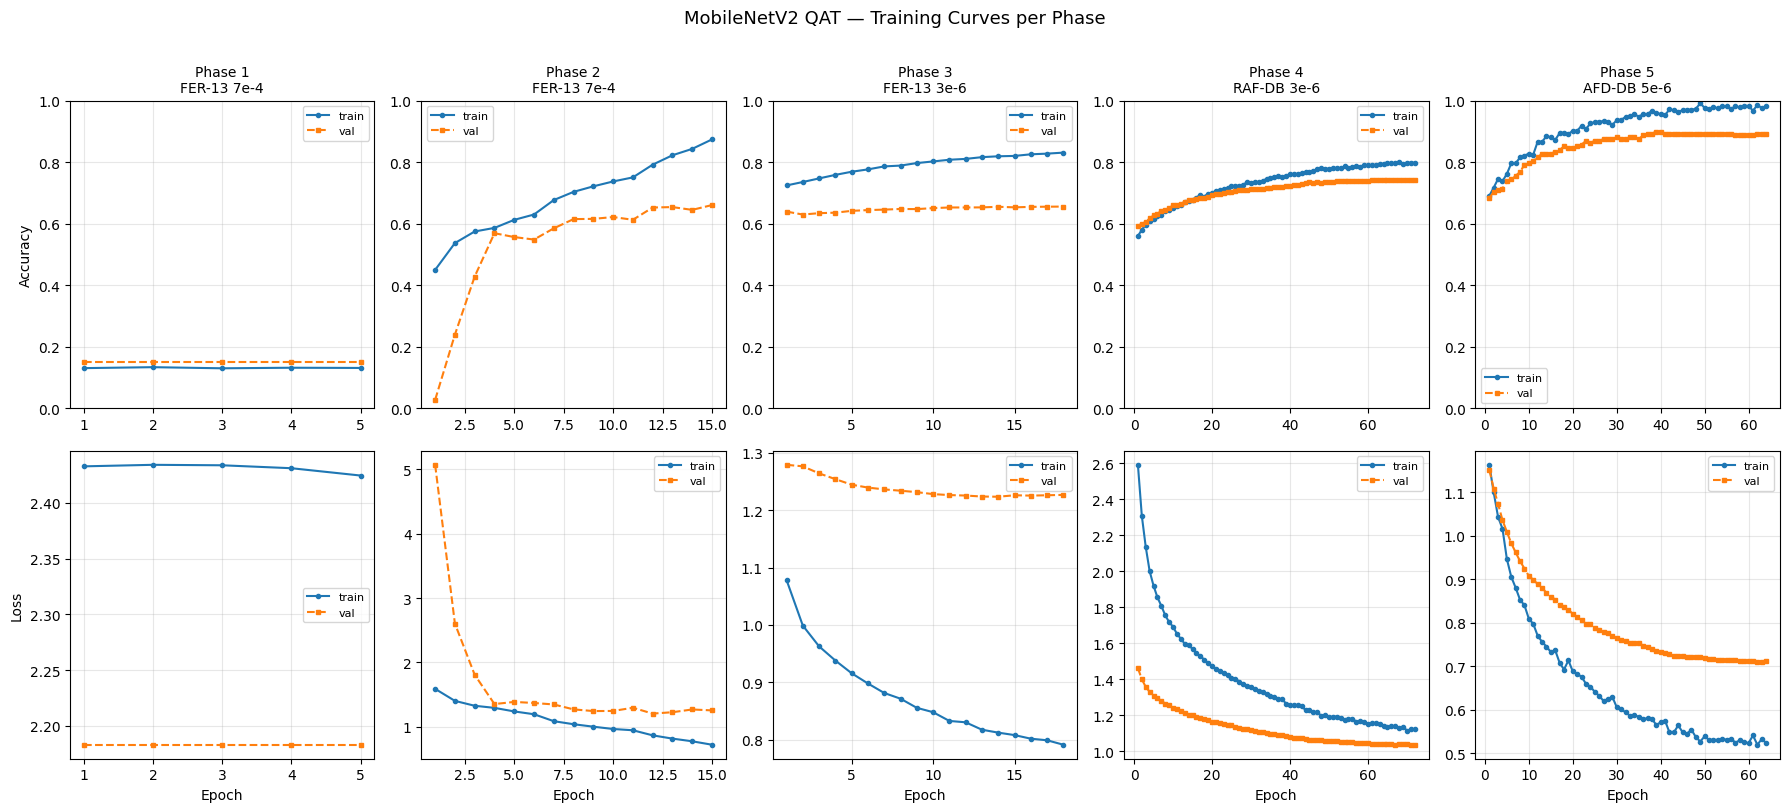

Plot saved → /kaggle/working/qat_phases/training_curves.png


In [22]:
all_histories = [
    ('Phase 1\nFER-13 7e-4', history_p1),
    ('Phase 2\nFER-13 7e-4', history_p2),
    ('Phase 3\nFER-13 3e-6', history_p3),
    ('Phase 4\nRAF-DB 3e-6', history_p4),
    ('Phase 5\nAFD-DB 5e-6', history_p5),
]

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.suptitle('MobileNetV2 QAT — Training Curves per Phase', fontsize=13, y=1.01)

for col, (title, hist) in enumerate(all_histories):
    epochs = range(1, len(hist.history['accuracy']) + 1)

    # Accuracy
    axes[0, col].plot(epochs, hist.history['accuracy'],     label='train', marker='o', ms=3)
    axes[0, col].plot(epochs, hist.history['val_accuracy'], label='val',   marker='s', ms=3, linestyle='--')
    axes[0, col].set_title(title, fontsize=10)
    axes[0, col].set_ylabel('Accuracy' if col == 0 else '')
    axes[0, col].set_ylim(0, 1)
    axes[0, col].legend(fontsize=8)
    axes[0, col].grid(True, alpha=0.3)

    # Loss
    axes[1, col].plot(epochs, hist.history['loss'],     label='train', marker='o', ms=3)
    axes[1, col].plot(epochs, hist.history['val_loss'], label='val',   marker='s', ms=3, linestyle='--')
    axes[1, col].set_ylabel('Loss' if col == 0 else '')
    axes[1, col].set_xlabel('Epoch')
    axes[1, col].legend(fontsize=8)
    axes[1, col].grid(True, alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(OUTPUT_DIR, 'training_curves.png')
plt.savefig(plot_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Plot saved → {plot_path}')

## Confusion Matrix

Found 28709 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.
Phase 1 FER-13 7e-4       — overall acc: 15.0%
Found 28709 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.
Phase 2 FER-13 7e-4       — overall acc: 66.0%
Found 28709 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.
Phase 3 FER-13 3e-6       — overall acc: 65.6%
Found 12271 files belonging to 7 classes.
Found 3068 files belonging to 7 classes.
Phase 4 RAF-DB 3e-6       — overall acc: 74.3%
Found 672 files belonging to 7 classes.
Found 168 files belonging to 7 classes.
Phase 5 AFD-DB 5e-6       — overall acc: 89.9%


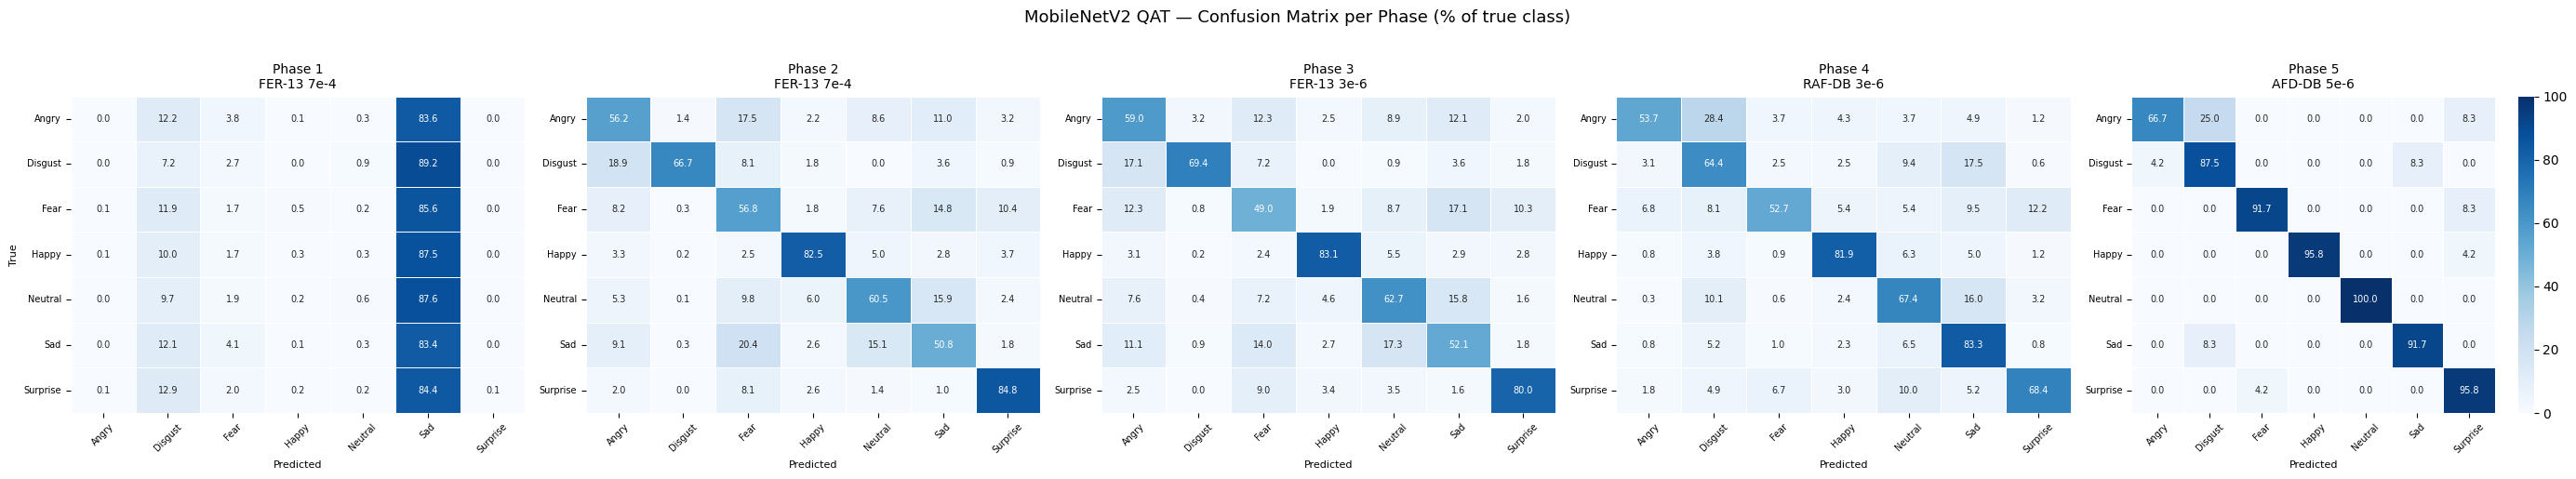

Saved → /kaggle/working/qat_phases/10th_trial_confusion_matrices.png


In [23]:

EMOTION_LABELS = ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']

phase_models = [
    ('Phase 1\nFER-13 7e-4',  os.path.join(OUTPUT_DIR, 'phase1_all_frozen_final_accuracy_0.1503.keras'),   'fer13'),
    ('Phase 2\nFER-13 7e-4',  os.path.join(OUTPUT_DIR, 'phase2_top90_frozen_final_accuracy_0.6605.keras'),  'fer13'),
    ('Phase 3\nFER-13 3e-6',  os.path.join(OUTPUT_DIR, 'phase3_top40_frozen_final_accuracy_0.6556.keras'),  'fer13'),
    ('Phase 4\nRAF-DB 3e-6',  os.path.join(OUTPUT_DIR, 'phase4_rafdb_final_accuracy_0.7435.keras'),         'rafdb'),
    ('Phase 5\nAFD-DB 5e-6',  os.path.join(OUTPUT_DIR, 'phase5_afd_final_accuracy_0.8988.keras'),         'afd'),
]

fig, axes = plt.subplots(1, 5, figsize=(28, 5))
fig.suptitle('MobileNetV2 QAT — Confusion Matrix per Phase (% of true class)', fontsize=13, y=1.02)

for col, (title, ckpt_path, dataset_name) in enumerate(phase_models):

    # ── Load phase model ──────────────────────────────────────────────
    with tfmot.quantization.keras.quantize_scope():
        phase_model = tf.keras.models.load_model(ckpt_path)

    # ── Get val dataset ───────────────────────────────────────────────
    _, val_ds = get_datasets(dataset_name)

    # ── Collect true labels + predictions ────────────────────────────
    y_true, y_pred = [], []
    for images, labels in val_ds:
        preds = phase_model.predict(images, verbose=0)
        y_true.extend(np.argmax(labels.numpy(), axis=1))
        y_pred.extend(np.argmax(preds, axis=1))

    # ── Confusion matrix normalised to % of true class (row-wise) ────
    cm = confusion_matrix(y_true, y_pred)
    cm_pct = (cm.astype(float) / cm.sum(axis=1, keepdims=True)) * 100

    # ── Plot ──────────────────────────────────────────────────────────
    sns.heatmap(
        cm_pct,
        ax=axes[col],
        annot=True,
        fmt='.1f',            # one decimal place e.g. 87.3
        cmap='Blues',
        vmin=0, vmax=100,
        xticklabels=EMOTION_LABELS,
        yticklabels=EMOTION_LABELS,
        linewidths=0.4,
        cbar=col == 4,        # only show colorbar on last plot
        annot_kws={'size': 7},
    )
    axes[col].set_title(title, fontsize=10)
    axes[col].set_xlabel('Predicted', fontsize=8)
    axes[col].set_ylabel('True' if col == 0 else '', fontsize=8)
    axes[col].tick_params(axis='x', rotation=45, labelsize=7)
    axes[col].tick_params(axis='y', rotation=0,  labelsize=7)

    # ── Print per-phase summary ───────────────────────────────────────
    overall_acc = np.diag(cm).sum() / cm.sum() * 100
    print(f'{title.replace(chr(10), " "):25s} — overall acc: {overall_acc:.1f}%')

    del phase_model
    gc.collect()

plt.tight_layout()
cm_path = os.path.join(OUTPUT_DIR, 'V2_9th_trial_confusion_matrices.png')
plt.savefig(cm_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved → {cm_path}')

# TFLite INT8 Conversion

In [24]:
print('Converting QAT model → TFLite INT8 ...')

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
# QAT already calibrated activation ranges — no representative
# dataset needed for INT8 conversion
tflite_bytes = converter.convert()

tflite_path = os.path.join(OUTPUT_DIR, 'final_qat_int8.tflite')
with open(tflite_path, 'wb') as f:
    f.write(tflite_bytes)

print(f'Saved → {tflite_path}')
print(f'File size : {len(tflite_bytes)/1024:.1f} KB')

Converting QAT model → TFLite INT8 ...
INFO:tensorflow:Assets written to: /tmp/tmpvaien14u/assets


INFO:tensorflow:Assets written to: /tmp/tmpvaien14u/assets


Saved → /kaggle/working/qat_phases/final_qat_int8.tflite
File size : 3220.5 KB


W0000 00:00:1780047478.105893     120 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1780047478.105949     120 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1780047478.328965     120 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


## TFLite Smoke Testing

In [25]:
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()

inp_detail  = interpreter.get_input_details()[0]
out_detail  = interpreter.get_output_details()[0]
dummy_input = np.random.rand(1, *IMAGE_SIZE, CHANNELS).astype(np.float32)

interpreter.set_tensor(inp_detail['index'], dummy_input)
interpreter.invoke()
preds = interpreter.get_tensor(out_detail['index'])

EMOTION_LABELS = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
print(f'Input  shape : {inp_detail["shape"]}  dtype: {inp_detail["dtype"]}')
print(f'Output shape : {out_detail["shape"]}  dtype: {out_detail["dtype"]}')
print(f'Predicted class : {EMOTION_LABELS[np.argmax(preds)]} ({preds.max():.3f})')
print('TFLite INT8 inference OK ✓')

Input  shape : [  1 224 224   3]  dtype: <class 'numpy.float32'>
Output shape : [1 7]  dtype: <class 'numpy.float32'>
Predicted class : neutral (0.313)
TFLite INT8 inference OK ✓


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


Found 28709 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.

═══════════════════════════════════════════════════════
  TFLite INT8 Evaluation — FER13 val set
═══════════════════════════════════════════════════════
  Overall Accuracy : 59.61%

  Class         Precision     Recall         F1    Support
  ────────────────────────────────────────────────────
  angry            64.52%     33.40%     44.02%        958
  disgust          19.58%     75.68%     31.11%        111
  fear             47.03%     30.96%     37.34%       1024
  happy            81.26%     85.57%     83.36%       1774
  neutral          53.10%     54.91%     53.99%       1233
  sad              48.80%     55.49%     51.93%       1247
  surprise         65.91%     80.75%     72.58%        831
  ────────────────────────────────────────────────────
  Macro avg        54.32%     59.54%     53.48%
  Weighted avg     60.94%     59.61%     58.98%


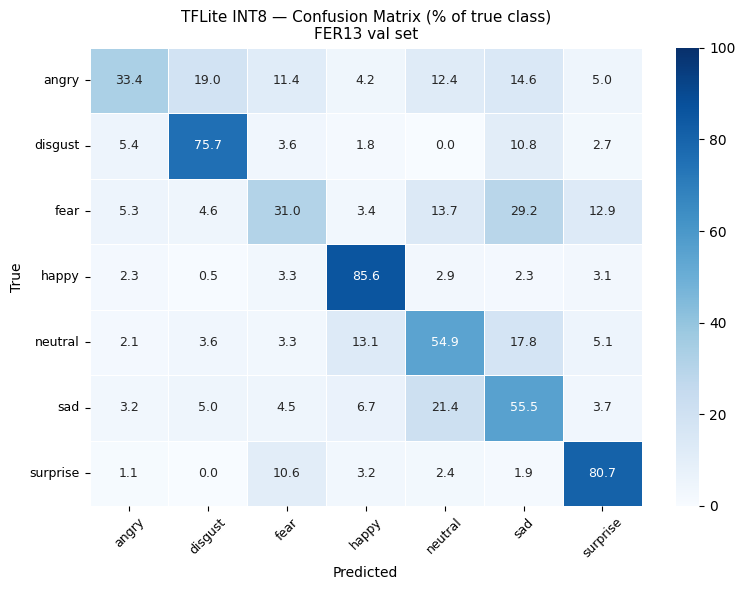


Confusion matrix saved → /kaggle/working/qat_phases/fer13_tflite_confusion_matrix.png
Found 12271 files belonging to 7 classes.
Found 3068 files belonging to 7 classes.

═══════════════════════════════════════════════════════
  TFLite INT8 Evaluation — RAFDB val set
═══════════════════════════════════════════════════════
  Overall Accuracy : 75.13%

  Class         Precision     Recall         F1    Support
  ────────────────────────────────────────────────────
  angry            69.12%     58.02%     63.09%        162
  disgust          40.48%     53.12%     45.95%        160
  fear             32.50%     52.70%     40.21%         74
  happy            94.01%     83.46%     88.42%       1185
  neutral          70.99%     75.59%     73.22%        680
  sad              64.72%     80.96%     71.93%        478
  surprise         86.40%     59.88%     70.74%        329
  ────────────────────────────────────────────────────
  Macro avg        65.46%     66.25%     64.79%
  Weighted avg   

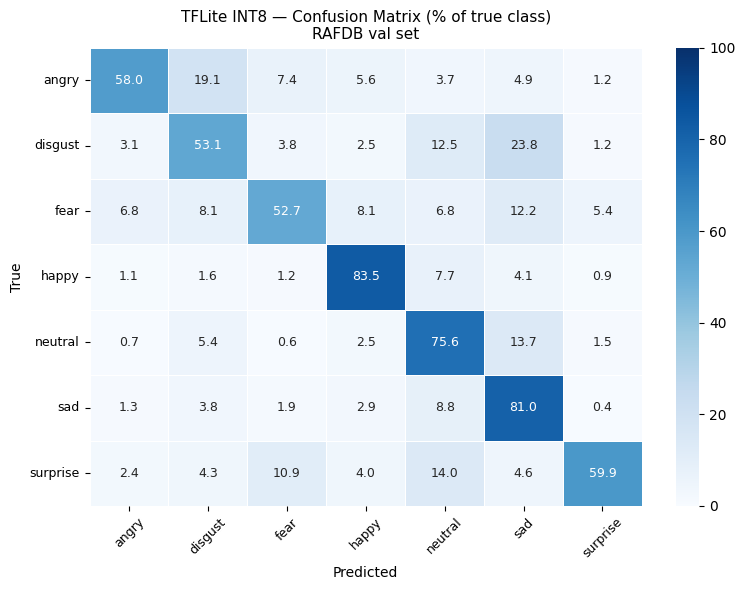


Confusion matrix saved → /kaggle/working/qat_phases/rafdb_tflite_confusion_matrix.png
Found 672 files belonging to 7 classes.
Found 168 files belonging to 7 classes.

═══════════════════════════════════════════════════════
  TFLite INT8 Evaluation — AFD val set
═══════════════════════════════════════════════════════
  Overall Accuracy : 83.33%

  Class         Precision     Recall         F1    Support
  ────────────────────────────────────────────────────
  angry           100.00%     37.50%     54.55%         24
  disgust          54.55%    100.00%     70.59%         24
  fear             95.00%     79.17%     86.36%         24
  happy           100.00%    100.00%    100.00%         24
  neutral         100.00%     83.33%     90.91%         24
  sad              91.30%     87.50%     89.36%         24
  surprise         82.14%     95.83%     88.46%         24
  ────────────────────────────────────────────────────
  Macro avg        89.00%     83.33%     82.89%
  Weighted avg     89.

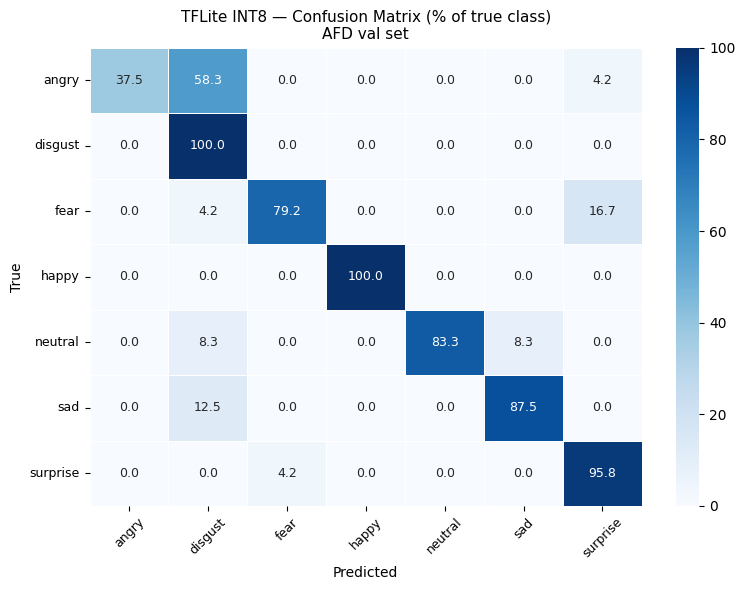


Confusion matrix saved → /kaggle/working/qat_phases/afd_tflite_confusion_matrix.png


In [26]:
def evaluate_tflite(tflite_path, dataset_name):
    """
    Run full evaluation on the TFLite INT8 model.
    Reports accuracy, precision, recall, F1 per class + overall.
    """

    # ── Load TFLite model ─────────────────────────────────────────────
    interpreter = tf.lite.Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()
    inp_detail = interpreter.get_input_details()[0]
    out_detail = interpreter.get_output_details()[0]

    # ── Run inference on full val set ─────────────────────────────────
    _, val_ds = get_datasets(dataset_name)

    y_true, y_pred, y_prob = [], [], []
    for images, labels in val_ds:
        for i in range(len(images)):
            img = images[i].numpy()[np.newaxis].astype(np.float32)  # (1, 224, 224, 3)
            interpreter.set_tensor(inp_detail['index'], img)
            interpreter.invoke()
            prob = interpreter.get_tensor(out_detail['index'])[0]   # (7,)
            y_true.append(np.argmax(labels[i].numpy()))
            y_pred.append(np.argmax(prob))
            y_prob.append(prob)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    # ── Overall metrics ───────────────────────────────────────────────
    overall_acc = (y_true == y_pred).mean() * 100
    print(f'\n{"═"*55}')
    print(f'  TFLite INT8 Evaluation — {dataset_name.upper()} val set')
    print(f'{"═"*55}')
    print(f'  Overall Accuracy : {overall_acc:.2f}%')

    # ── Per-class report ──────────────────────────────────────────────
    report = classification_report(
        y_true, y_pred,
        target_names=EMOTION_LABELS,
        digits=4,
        output_dict=True,
    )

    # Print formatted table
    print(f'\n  {"Class":<12} {"Precision":>10} {"Recall":>10} {"F1":>10} {"Support":>10}')
    print(f'  {"─"*52}')
    for label in EMOTION_LABELS:
        r = report[label]
        print(
            f'  {label:<12}'
            f'  {r["precision"]*100:>8.2f}%'
            f'  {r["recall"]*100:>8.2f}%'
            f'  {r["f1-score"]*100:>8.2f}%'
            f'  {int(r["support"]):>9}'
        )
    print(f'  {"─"*52}')
    macro = report['macro avg']
    print(
        f'  {"Macro avg":<12}'
        f'  {macro["precision"]*100:>8.2f}%'
        f'  {macro["recall"]*100:>8.2f}%'
        f'  {macro["f1-score"]*100:>8.2f}%'
    )
    weighted = report['weighted avg']
    print(
        f'  {"Weighted avg":<12}'
        f'  {weighted["precision"]*100:>8.2f}%'
        f'  {weighted["recall"]*100:>8.2f}%'
        f'  {weighted["f1-score"]*100:>8.2f}%'
    )

    # ── Confusion matrix ──────────────────────────────────────────────
    cm = confusion_matrix(y_true, y_pred)
    cm_pct = (cm.astype(float) / cm.sum(axis=1, keepdims=True)) * 100

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        cm_pct, ax=ax,
        annot=True, fmt='.1f', cmap='Blues',
        vmin=0, vmax=100,
        xticklabels=EMOTION_LABELS,
        yticklabels=EMOTION_LABELS,
        linewidths=0.4,
        annot_kws={'size': 9},
    )
    ax.set_title(f'TFLite INT8 — Confusion Matrix (% of true class)\n{dataset_name.upper()} val set', fontsize=11)
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('True', fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ax.tick_params(axis='y', rotation=0,  labelsize=9)
    plt.tight_layout()

    cm_path = os.path.join(OUTPUT_DIR, f'{dataset_name}_tflite_confusion_matrix.png')
    plt.savefig(cm_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'\nConfusion matrix saved → {cm_path}')

    return report


# ── Run it ────────────────────────────────────────────────────────────
tflite_report = evaluate_tflite(tflite_path, dataset_name='fer13')
tflite_report = evaluate_tflite(tflite_path, dataset_name='rafdb')
tflite_report = evaluate_tflite(tflite_path, dataset_name='afd')

# Model Save and Export

In [27]:
# Only put in the model file name
model.export("phase5_afd_final_accuracy_0.8988")

print("Model ready to be zip")

INFO:tensorflow:Assets written to: phase5_afd_final_accuracy_0.8988/assets


INFO:tensorflow:Assets written to: phase5_afd_final_accuracy_0.8988/assets


Saved artifact at 'phase5_afd_final_accuracy_0.8988'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_1')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  134739629685648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134739629684688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134739629684880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134739629684496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134739629683920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134739629685264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134739629686416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134739629685840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134738964444944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134738964446288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134

In [28]:
import shutil

# put in the path of the new exported model folder
shutil.make_archive("/kaggle/working/phase5_afd_final_accuracy_0.8988", 'zip', "/kaggle/working/phase5_afd_final_accuracy_0.8988")

'/kaggle/working/phase5_afd_final_accuracy_0.8988.zip'

# Output Summary

In [29]:
print('\n── All phase results ──────────────────────────────────')
for label, hist in [
    ('Phase 1 (FER-13 7e-4)', history_p1),
    ('Phase 2 (FER-13 7e-4)', history_p2),
    ('Phase 3 (FER-13 3e-6)', history_p3),
    ('Phase 4 (RAF-DB 3e-6)', history_p4),
    ('Phase 5 (AFD-DB 5e-6)', history_p5),
]:
    best_acc       = max(hist.history['val_accuracy'])
    best_loss      = min(hist.history['val_loss'])
    n_ep           = len(hist.history['val_accuracy'])
    best_precision = max(hist.history['val_precision'])
    print(f'{label:30s}  epochs={n_ep:2d}  val_acc={best_acc:.4f}  val_loss={best_loss:.4f}   val_precision={best_precision:.4f}')

print('\n── Output files ───────────────────────────────────────')
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, fname)
    if os.path.isfile(fpath):
        kb = os.path.getsize(fpath) / 1024
        print(f'  {fname:<45s} {kb:>8.0f} KB')


── All phase results ──────────────────────────────────
Phase 1 (FER-13 7e-4)           epochs= 5  val_acc=0.1503  val_loss=2.1832   val_precision=0.1385
Phase 2 (FER-13 7e-4)           epochs=15  val_acc=0.6605  val_loss=1.2045   val_precision=0.7431
Phase 3 (FER-13 3e-6)           epochs=18  val_acc=0.6556  val_loss=1.2235   val_precision=0.7145
Phase 4 (RAF-DB 3e-6)           epochs=72  val_acc=0.7435  val_loss=1.0353   val_precision=0.8133
Phase 5 (AFD-DB 5e-6)           epochs=64  val_acc=0.8988  val_loss=0.7107   val_precision=0.9187

── Output files ───────────────────────────────────────
  10th_trial_confusion_matrices.png                  128 KB
  afd_tflite_confusion_matrix.png                     54 KB
  base_model.keras                                 12412 KB
  fer13_tflite_confusion_matrix.png                   66 KB
  final_qat_int8.tflite                             3220 KB
  phase1_all_frozen_best.keras                     12424 KB
  phase1_all_frozen_final_accuracy_0